In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/dataset.csv")


In [2]:
df.info

<bound method DataFrame.info of      CUST_ID      BALANCE  PURCHASES  ONEOFF_PURCHASES  \
0     C10001    40.900749      95.40              0.00   
1     C10002  3202.467416       0.00              0.00   
2     C10003  2495.148862     773.17            773.17   
3     C10004  1666.670542    1499.00           1499.00   
4     C10005   817.714335      16.00             16.00   
...      ...          ...        ...               ...   
8945  C19186    28.493517     291.12              0.00   
8946  C19187    19.183215     300.00              0.00   
8947  C19188    23.398673     144.40              0.00   
8948  C19189    13.457564       0.00              0.00   
8949  C19190   372.708075    1093.25           1093.25   

      INSTALLMENTS_PURCHASES  CASH_ADVANCE  CREDIT_LIMIT     PAYMENTS  
0                      95.40      0.000000        1000.0   201.802084  
1                       0.00   6442.945483        7000.0  4103.032597  
2                       0.00      0.000000        7500.

En observent que y a des valeurs manquant dans la colonne de "Credit Limit" :

In [3]:
df.isnull().sum()

CUST_ID                   0
BALANCE                   0
PURCHASES                 0
ONEOFF_PURCHASES          0
INSTALLMENTS_PURCHASES    0
CASH_ADVANCE              0
CREDIT_LIMIT              1
PAYMENTS                  0
dtype: int64

In [4]:
df.describe()


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000
mean,1564.474828,1003.204834,592.437371,411.067645,978.871112,4494.449450,1733.143852
std,2081.531879,2136.634782,1659.887917,904.338115,2097.163877,3638.815725,2895.063757
min,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000
25%,128.281915,39.635000,0.000000,0.000000,0.000000,1600.000000,383.276166
50%,873.385231,361.280000,38.000000,89.000000,0.000000,3000.000000,856.901546
75%,2054.140036,1110.130000,577.405000,468.637500,1113.821139,6500.000000,1901.134317
max,19043.138560,49039.570000,40761.250000,22500.000000,47137.211760,30000.000000,50721.483360


In [5]:
df.shape

(8950, 8)

In [6]:
# le nombre de duplication est null :
df.duplicated().sum()

np.int64(0)

In [7]:
from scipy.stats import skew 
import matplotlib.pyplot as plt
import seaborn as sns

skewness = skew(df["CREDIT_LIMIT"],axis=0, bias=True)
print(skewness)

nan


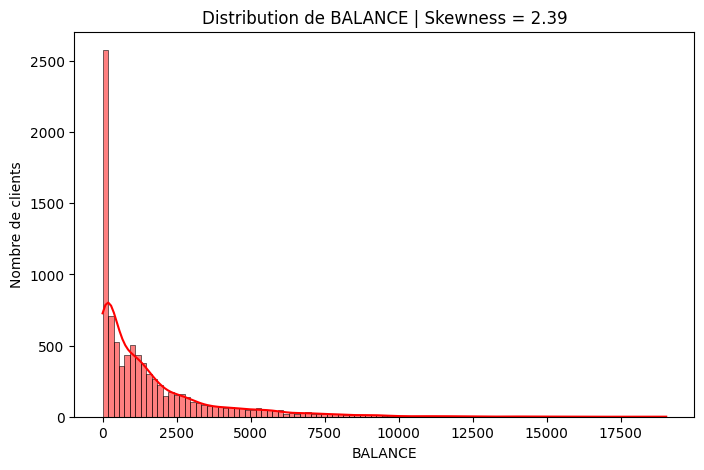

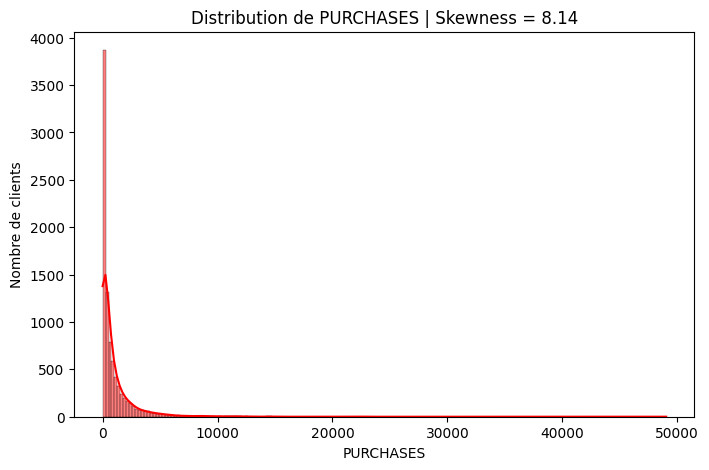

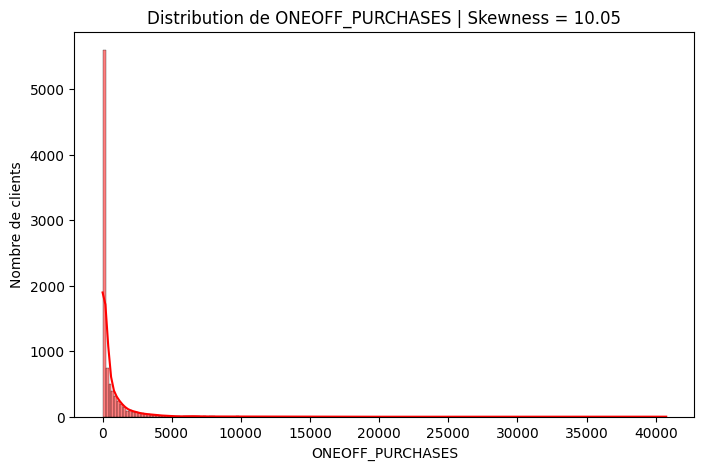

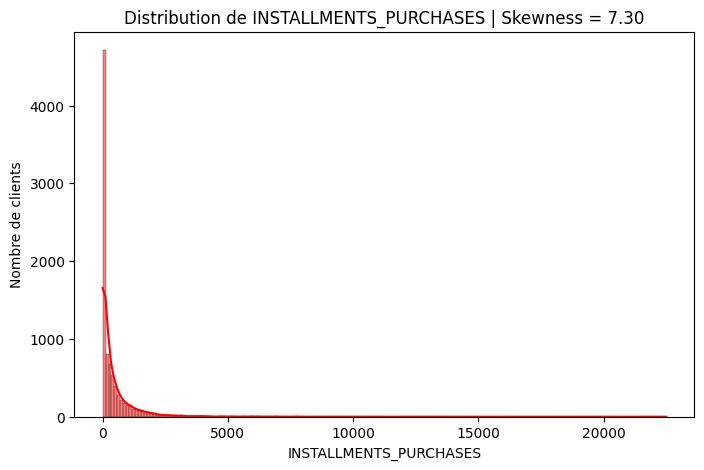

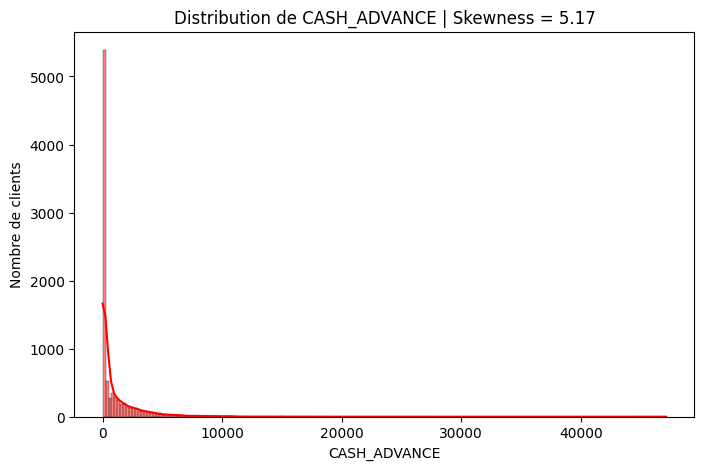

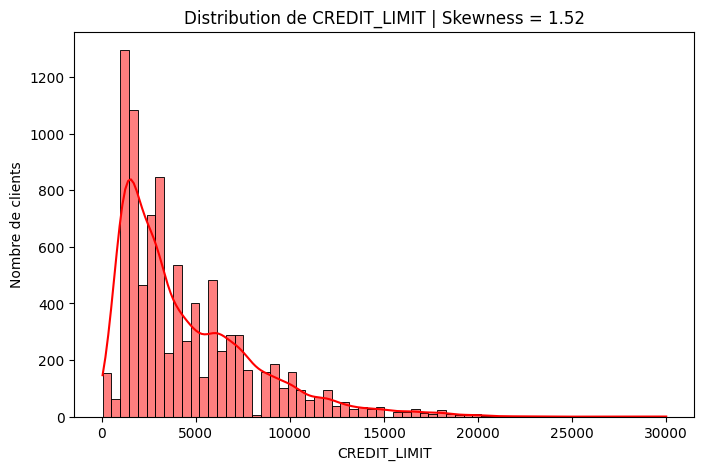

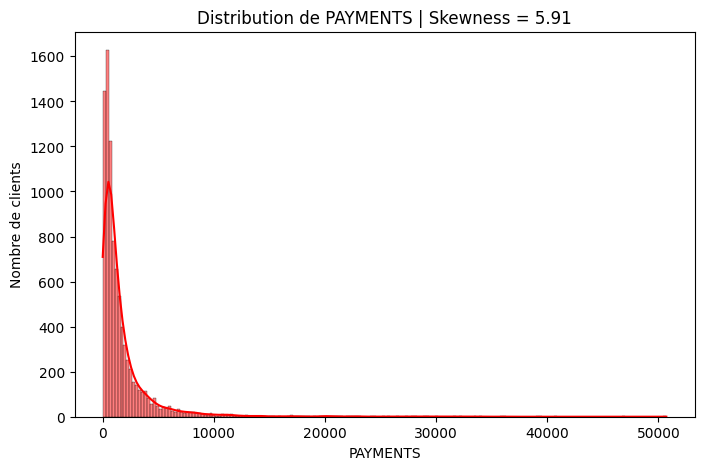

,Variable,Skewness,Abs_Skewness
2,ONEOFF_PURCHASES,10.045083,10.045083
1,PURCHASES,8.144269,8.144269
3,INSTALLMENTS_PURCHASES,7.299120,7.299120
6,PAYMENTS,5.907620,5.907620
4,CASH_ADVANCE,5.166609,5.166609
0,BALANCE,2.393386,2.393386
5,CREDIT_LIMIT,1.522464,1.522464


,mean,median,std,min,max
BALANCE,1564.474828,873.385231,2081.531879,0.0,19043.13856
PURCHASES,1003.204834,361.280000,2136.634782,0.0,49039.57000
ONEOFF_PURCHASES,592.437371,38.000000,1659.887917,0.0,40761.25000
INSTALLMENTS_PURCHASES,411.067645,89.000000,904.338115,0.0,22500.00000
CASH_ADVANCE,978.871112,0.000000,2097.163877,0.0,47137.21176
CREDIT_LIMIT,4494.449450,3000.000000,3638.815725,50.0,30000.00000
PAYMENTS,1733.143852,856.901546,2895.063757,0.0,50721.48336


In [8]:
#variables comportementales numeriques:

numeriqie_cols = ["BALANCE","PURCHASES","ONEOFF_PURCHASES","INSTALLMENTS_PURCHASES","CASH_ADVANCE","CREDIT_LIMIT","PAYMENTS"]

missing_table = pd.DataFrame({"Missing_Count": df[numeriqie_cols].isnull().sum(),"Missing_%": df[numeriqie_cols].isnull().mean() * 100})

#distribution et Skewness

for col in numeriqie_cols:

    skew = df[col].skew()
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df,x=col,kde=True,color='red')

    plt.title(f"Distribution de {col} | Skewness = {skew:.2f}")

    plt.xlabel(col)
    plt.ylabel("Nombre de clients")
    plt.show()

skew_table = pd.DataFrame({"Variable": numeriqie_cols,"Skewness": [df[col].skew() for col in numeriqie_cols]})

skew_table["Abs_Skewness"] = skew_table["Skewness"].abs()

skew_table = skew_table.sort_values(by="Abs_Skewness",ascending=False)

display(skew_table)


distribution_stats = df[numeriqie_cols].agg(["mean", "median", "std", "min", "max"]).T

display(distribution_stats)

In [9]:
numeric_cols = df.select_dtypes(include="number").columns

print(numeric_cols)

numeric_cols = [
    col for col in df.select_dtypes(include="number").columns
    if col != "CUST_ID"
]

Index(['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
       'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS'],
      dtype='object')


In [10]:
# en va voir les statistiques:

distribution_stats = pd.DataFrame({
    "Count": df[numeric_cols].count(),
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Std": df[numeric_cols].std(),
    "Min": df[numeric_cols].min(),
    "Max": df[numeric_cols].max(),
    "Skewness": df[numeric_cols].skew()
})

distribution_stats

,Count,Mean,Median,Std,Min,Max,Skewness
BALANCE,8950,1564.474828,873.385231,2081.531879,0.0,19043.13856,2.393386
PURCHASES,8950,1003.204834,361.280000,2136.634782,0.0,49039.57000,8.144269
ONEOFF_PURCHASES,8950,592.437371,38.000000,1659.887917,0.0,40761.25000,10.045083
INSTALLMENTS_PURCHASES,8950,411.067645,89.000000,904.338115,0.0,22500.00000,7.299120
CASH_ADVANCE,8950,978.871112,0.000000,2097.163877,0.0,47137.21176,5.166609
CREDIT_LIMIT,8949,4494.449450,3000.000000,3638.815725,50.0,30000.00000,1.522464
PAYMENTS,8950,1733.143852,856.901546,2895.063757,0.0,50721.48336,5.907620


- Histogram + KDE + Skewness

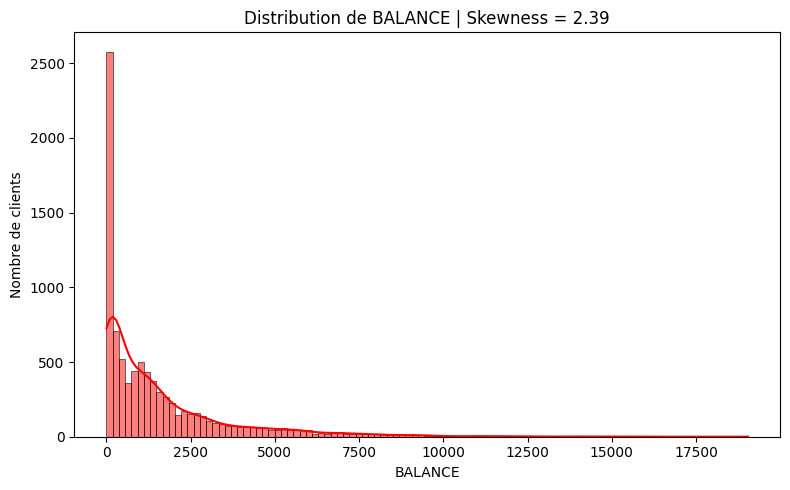

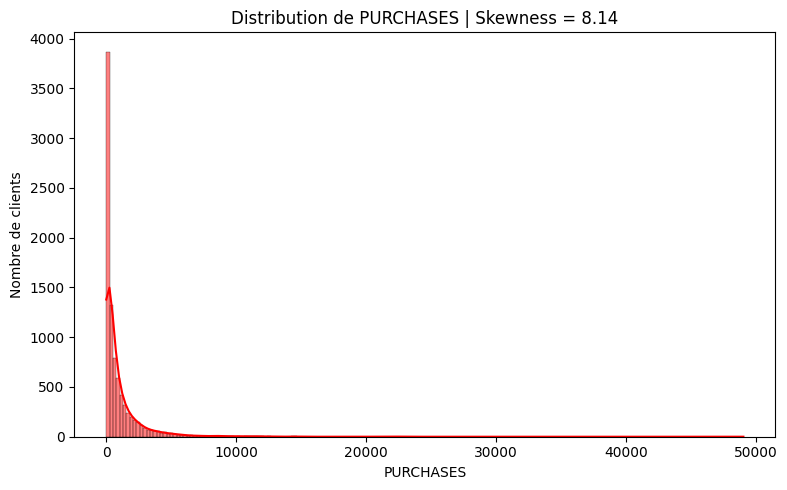

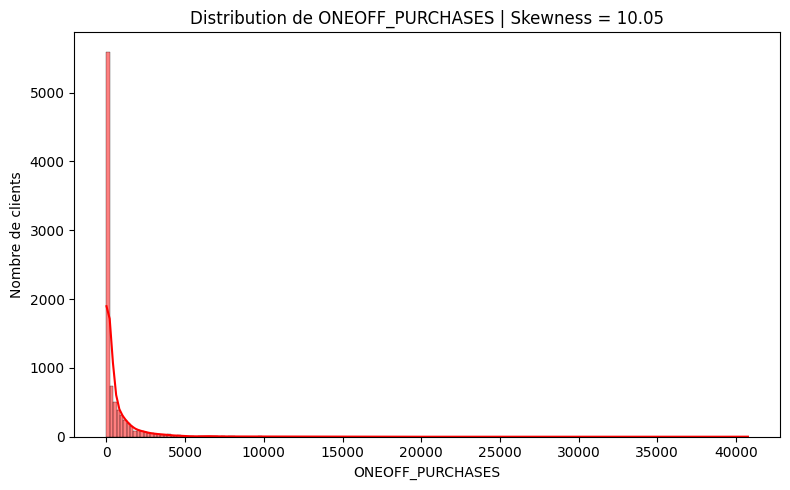

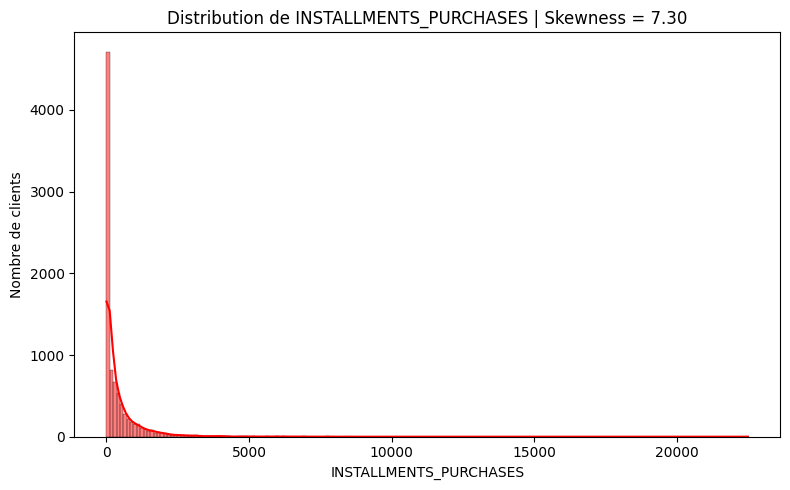

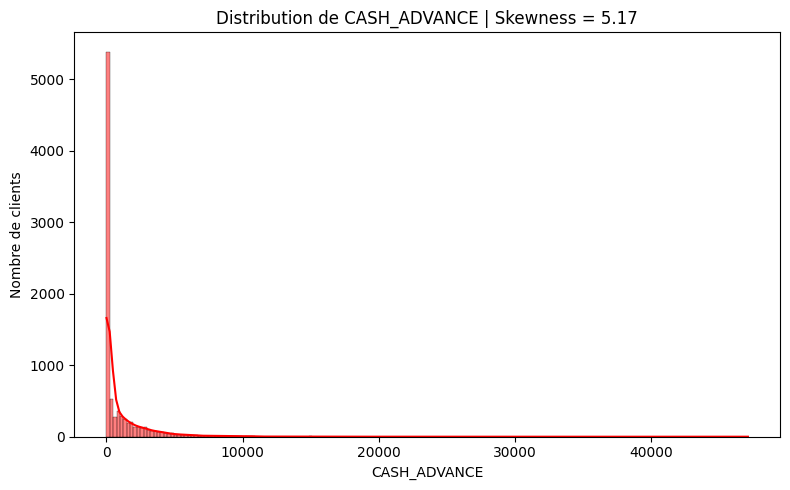

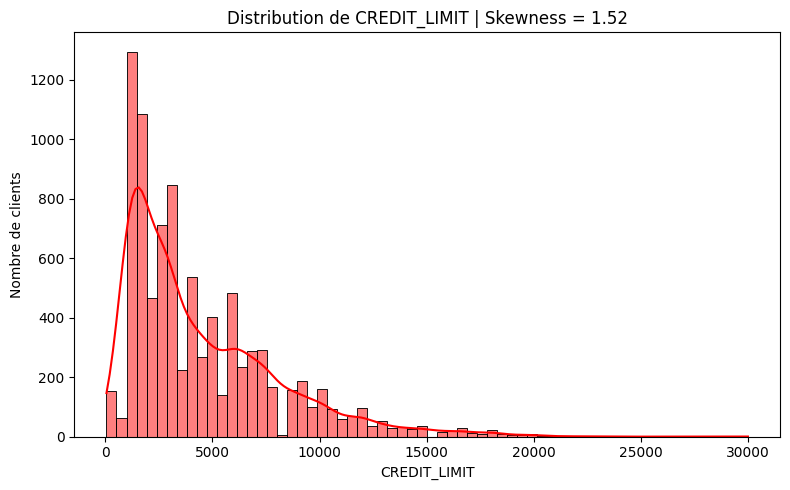

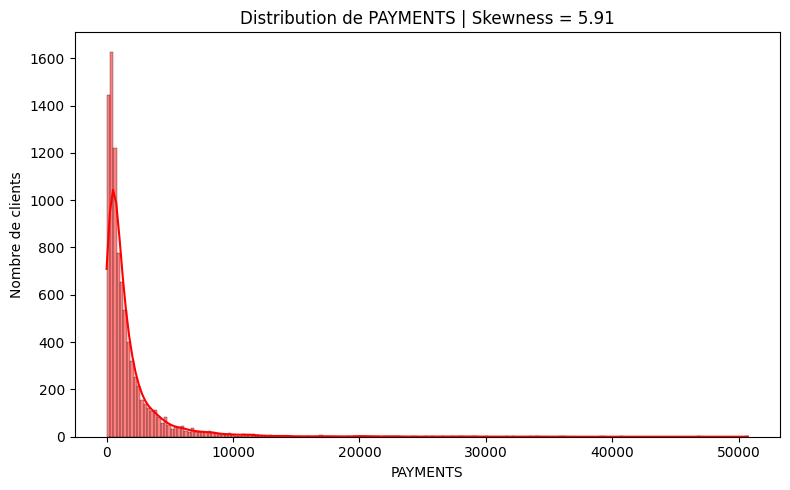

In [11]:
for col in numeric_cols:

    skewness = df[col].skew()

    plt.figure(figsize=(8, 5))

    sns.histplot(data=df, x=col,kde=True,color='red')

    plt.title(f"Distribution de {col} | Skewness = {skewness:.2f}")

    plt.xlabel(col)
    plt.ylabel("Nombre de clients")

    plt.tight_layout()
    plt.show()

- Étudier les corrélations entre variables (heatmap de la matrice de corrélation).

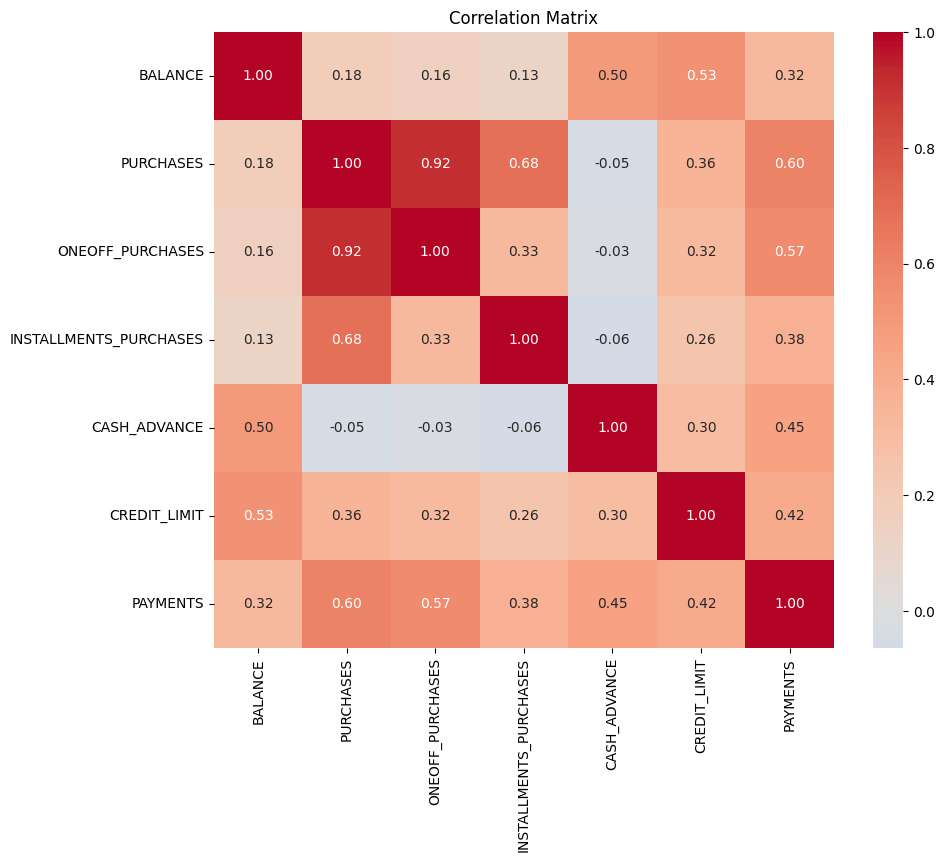

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap( corr,  annot=True,   fmt=".2f",   cmap="coolwarm",  center=0)

plt.title("Correlation Matrix")
plt.show()

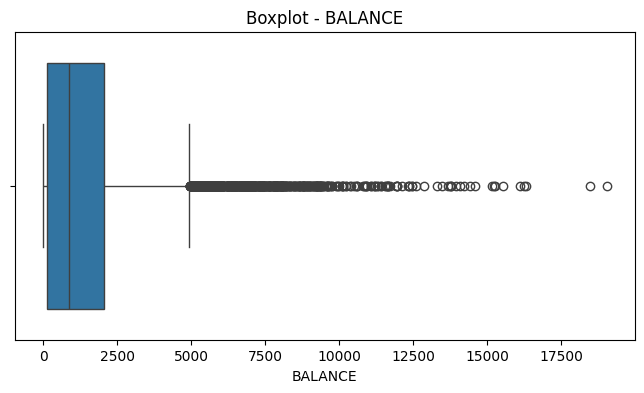

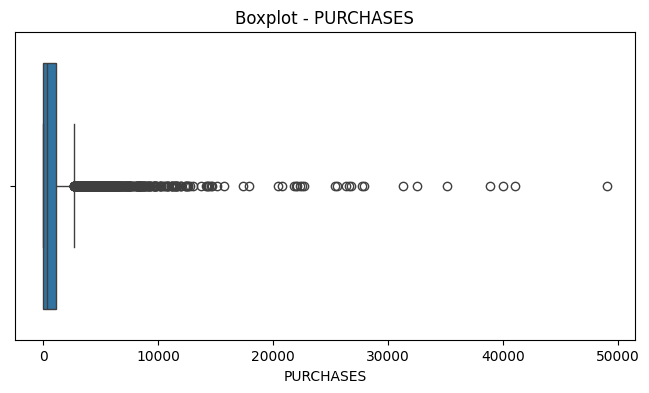

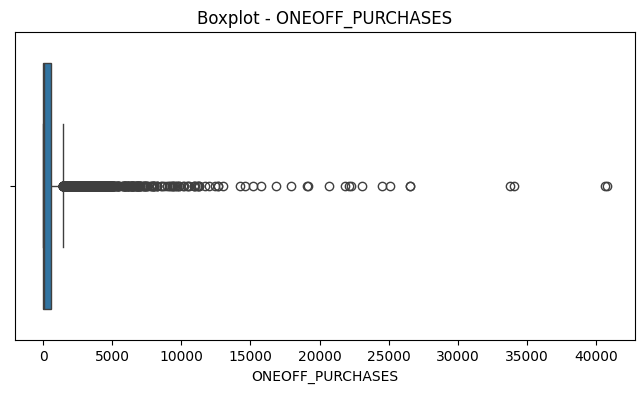

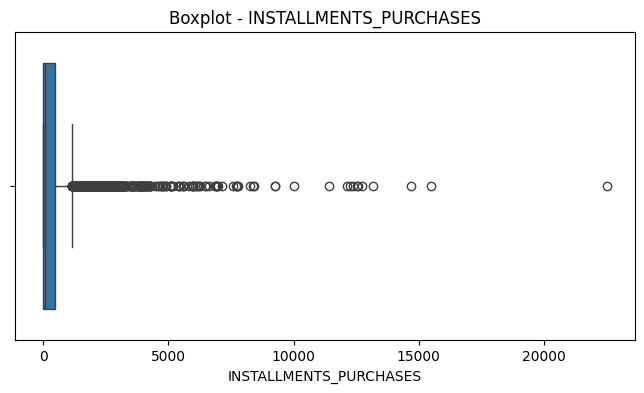

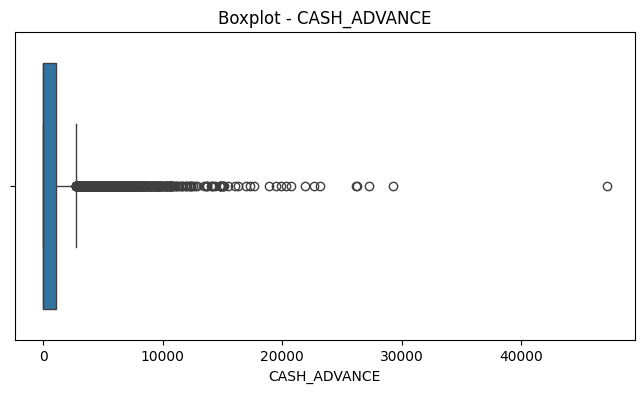

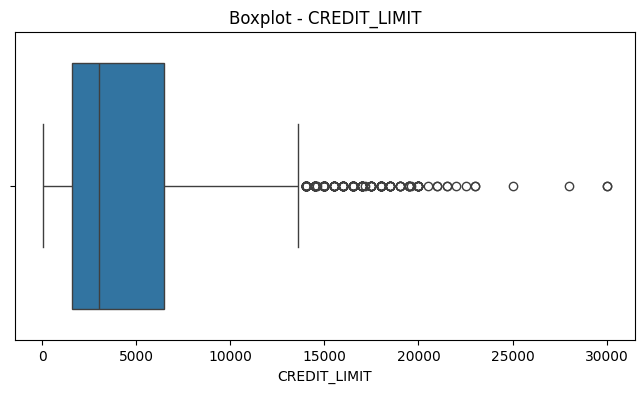

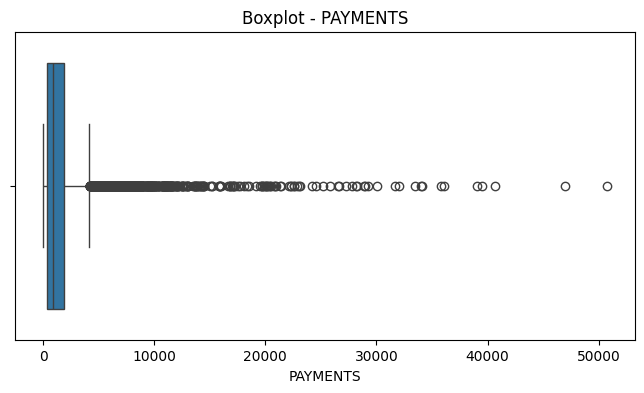

In [13]:
# detection les valeurs aberrants :

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()

In [14]:
outliers_sm = []

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    outliers_sm.append({
        "Variable": col,
        "Skewness": df[col].skew(),
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Nb_Outliers": len(outliers),
        "Outlier_%": len(outliers) / len(df) * 100
    })

outliers_df = pd.DataFrame(outliers_sm)

outliers_df

,Variable,Skewness,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Nb_Outliers,Outlier_%
0,BALANCE,2.393386,128.281915,2054.140036,1925.858120,-2760.505265,4942.927215,695,7.765363
1,PURCHASES,8.144269,39.635000,1110.130000,1070.495000,-1566.107500,2715.872500,808,9.027933
2,ONEOFF_PURCHASES,10.045083,0.000000,577.405000,577.405000,-866.107500,1443.512500,1013,11.318436
3,INSTALLMENTS_PURCHASES,7.299120,0.000000,468.637500,468.637500,-702.956250,1171.593750,867,9.687151
4,CASH_ADVANCE,5.166609,0.000000,1113.821139,1113.821139,-1670.731709,2784.552848,1030,11.508380
5,CREDIT_LIMIT,1.522464,1600.000000,6500.000000,4900.000000,-5750.000000,13850.000000,248,2.770950
6,PAYMENTS,5.907620,383.276166,1901.134317,1517.858151,-1893.511060,4177.921543,808,9.027933
